

```
Práctica N°6 - Aprendizaje Profundo
```



# **CLASIFICACIÓN DE DATOS ESTRUCTURADOS MEDIANTE EMBEDDINGS**

*Dataset: Heart Disease Dataset (UCI Machine Learning Repository)*

## 1. Librerías

In [1]:
!pip install -q fastai

from fastai.tabular.all import *
import pandas as pd
import numpy as np
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

## 2. Dataset

In [3]:
# Columnas del dataset
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

# Copia espejo del mismo archivo processed.cleveland.data
url = "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data"

df = pd.read_csv(url, header=None, names=columns)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Limpieza de datos

In [4]:
# Reemplazar '?' por NaN
df = df.replace('?', np.nan)

# Convertir a numérico
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ver valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## 4. Corrección clave: variable objetivo como categórica

In [5]:
# Convertimos target a binario (0 = no enfermedad, 1 = enfermedad)
df['target'] = (df['target'] > 0).astype(int)

# IMPORTANTE: la variable objetivo debe ser categórica para que FastAI
# lo trate como clasificación y no como regresión
df['target'] = df['target'].astype('category')

print(df['target'].value_counts())
print(df['target'].dtype)


target
0    164
1    139
Name: count, dtype: int64
category


## 5. Variables categóricas y continuas

In [6]:
# Variables categóricas reales
cat_names = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Convertirlas a categóricas
for col in cat_names:
    df[col] = df[col].astype('category')

# Variables continuas
cont_names = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Variable objetivo
dep_var = 'target'

print("Variables categóricas:", cat_names)
print("Variables continuas:", cont_names)
print(df.dtypes)


Variables categóricas: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Variables continuas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
target      category
dtype: object


## 6. División train/test

In [7]:
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Tamaño train:", df_train.shape)
print("Tamaño test:", df_test.shape)


Tamaño train: (242, 14)
Tamaño test: (61, 14)


## 7. Definición del DataLoader

In [8]:
# Transformaciones de FastAI
procs = [Categorify, FillMissing, Normalize]

# Creamos índices de validación aleatorios dentro de train
valid_idx = random.sample(range(0, len(df_train)), int(len(df_train) * 0.2))

# DataLoader para entrenamiento y validación
dls_train = TabularDataLoaders.from_df(
    df_train,
    path='.',
    procs=procs,
    cat_names=cat_names,
    cont_names=cont_names,
    y_names=dep_var,
    valid_idx=valid_idx,
    bs=32
)

dls_train.show_batch()


,sex,cp,fbs,restecg,exang,slope,ca,thal,age,trestbps,chol,thalach,oldpeak,target
0,1.0,4.0,0.0,2.0,1.0,2.0,0.0,7.0,40.000000,110.000001,167.000002,114.000001,2.000000e+00,1
1,0.0,4.0,0.0,0.0,0.0,1.0,0.0,3.0,49.000000,130.000000,269.000000,163.000000,-2.575833e-08,0
2,0.0,3.0,0.0,0.0,0.0,2.0,0.0,3.0,42.000000,120.000000,209.000000,173.000001,-2.575833e-08,0
3,1.0,2.0,0.0,0.0,1.0,1.0,0.0,3.0,59.000000,140.000000,221.000000,164.000000,-2.575833e-08,0
4,1.0,4.0,0.0,2.0,1.0,2.0,2.0,3.0,66.999999,100.000000,298.999999,124.999999,9.000000e-01,1
5,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,52.000000,120.000000,324.999998,171.999999,2.000000e-01,0
6,1.0,2.0,0.0,2.0,0.0,1.0,1.0,7.0,54.000000,192.000000,283.000000,195.000000,-2.575833e-08,1
7,1.0,3.0,1.0,2.0,0.0,1.0,0.0,3.0,58.000000,140.000000,210.999999,165.000000,-2.575833e-08,0
8,0.0,3.0,0.0,2.0,0.0,1.0,1.0,3.0,51.000000,140.000000,308.000001,142.000000,1.500000e+00,0
9,1.0,2.0,0.0,0.0,1.0,1.0,0.0,3.0,59.000000,140.000000,221.000000,164.000000,-2.575833e-08,0


## 8. Modelo

In [9]:
learn = tabular_learner(
    dls_train,
    layers=[256, 128],
    metrics=[accuracy]
)

learn.model


TabularModel(
  (embeds): ModuleList(
    (0): Embedding(3, 3)
    (1): Embedding(5, 4)
    (2): Embedding(3, 3)
    (3): Embedding(4, 3)
    (4): Embedding(3, 3)
    (5): Embedding(4, 3)
    (6): Embedding(5, 4)
    (7): Embedding(4, 3)
  )
  (emb_drop): Dropout(p=0.0, inplace=False)
  (bn_cont): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): LinBnDrop(
      (0): Linear(in_features=31, out_features=256, bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): LinBnDrop(
      (0): Linear(in_features=256, out_features=128, bias=False)
      (1): ReLU(inplace=True)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): LinBnDrop(
      (0): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)

## 9. Búsqueda del learning rate

<div></div>

Learning rate sugerido (valley): 0.013182567432522774


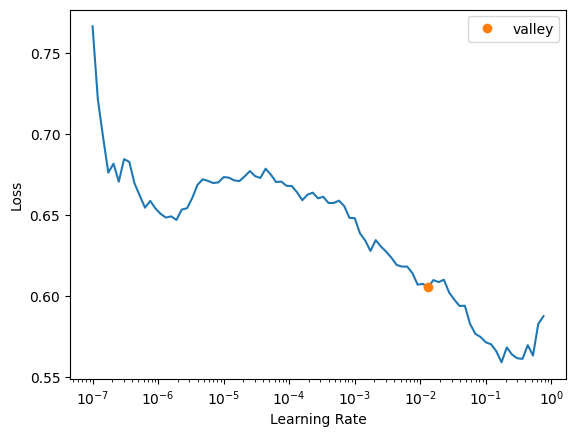

In [10]:
lr_suggestion = learn.lr_find()

print("Learning rate sugerido (valley):", lr_suggestion.valley)

# Guardamos el learning rate recomendado
lr_value = lr_suggestion.valley


## 10. Entrenamiento del modelo

In [11]:
learn.fit_one_cycle(20, lr_max=lr_value)


epoch,train_loss,valid_loss,accuracy,time
0,0.634609,0.645383,0.708333,00:00
1,0.609910,0.618193,0.708333,00:00
2,0.603919,0.540164,0.729167,00:00
3,0.568333,0.512381,0.791667,00:00
4,0.525416,0.430756,0.854167,00:00
5,0.479820,0.573028,0.854167,00:00
6,0.442813,0.638507,0.812500,00:00
7,0.406922,0.644008,0.812500,00:00
8,0.365520,0.694508,0.833333,00:00
9,0.347425,0.620028,0.854167,00:00


## 11. Evaluación en el conjunto de test

In [12]:
# Unimos train y test para construir un DataLoader donde la validación sea el test
df_all = pd.concat([df_train, df_test], ignore_index=True)

# Índices del conjunto de test
test_idx = list(range(len(df_train), len(df_all)))

# DataLoader para evaluación final
dls_test = TabularDataLoaders.from_df(
    df_all,
    path='.',
    procs=procs,
    cat_names=cat_names,
    cont_names=cont_names,
    y_names=dep_var,
    valid_idx=test_idx,
    bs=32
)

# Reemplazamos los dataloaders del learner
learn.dls = dls_test

# Métricas en test
test_metrics = learn.validate()
print("Loss en test:", test_metrics[0])
print("Accuracy en test:", test_metrics[1])


Loss en test: 0.35061290860176086
Accuracy en test: 0.8524590134620667


## 12. Matriz de confusión y reporte de clasificación

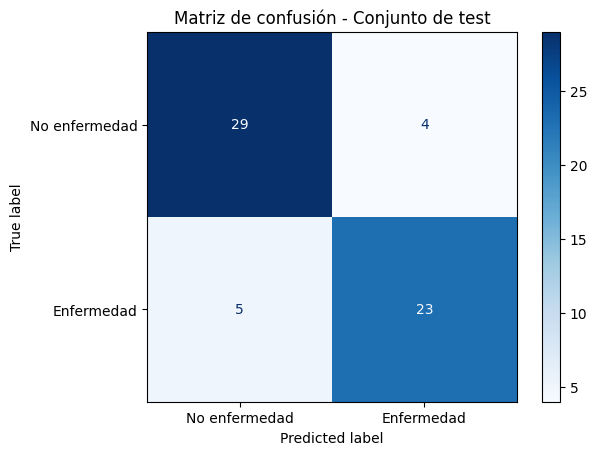

               precision    recall  f1-score   support

No enfermedad       0.85      0.88      0.87        33
   Enfermedad       0.85      0.82      0.84        28

     accuracy                           0.85        61
    macro avg       0.85      0.85      0.85        61
 weighted avg       0.85      0.85      0.85        61



In [13]:
preds, targs = learn.get_preds(dl=learn.dls.valid)

# Convertimos probabilidades a clases
y_pred = preds.argmax(dim=1).numpy()
y_true = targs.numpy()

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No enfermedad', 'Enfermedad']
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión - Conjunto de test')
plt.show()

# Reporte de clasificación
print(classification_report(y_true, y_pred, target_names=['No enfermedad', 'Enfermedad']))


## 13. Predicción de ejemplo

In [14]:
# Seleccionamos una muestra del dataset
sample = df.iloc[0]

# Realizamos la predicción
row, pred_idx, pred_probs = learn.predict(sample)

# Obtener nombres de las clases
clases = dls_train.vocab

# Mostrar resultados
print("Clase predicha:", clases[pred_idx])
print("Probabilidades:", pred_probs)


Clase predicha: 0
Probabilidades: tensor([0.9744, 0.0256])
